## Zadanie 3

Dany jest sztuczny „genom” o sekwencji:
ATGATTTCCTCTCCTCGATTCCGCCAATC
Przyjmujemy długość k-mera k = 6.

**3a. Lista k-merów**

1) Wypisz wszystkie k-mery długości 6 występujące w genomie (kolejno od pozycji 1).
2) Dla każdego k-mera wypisz:
    - prefix = pierwsze 5 nukleotydów (k–1),
    - suﬃx = ostatnie 5 nukleotydów (k–1).

In [25]:
sequence = "ATGATTTCCTCTCCTCGATTCCGCCAATC"
kmer_length = 6

def create_kmer(sequence, k):
    kmers = []
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i + k]
        kmers.append(kmer)
    return kmers

def create_prefix(kmers):
    prefixes = [kmer[:-1] for kmer in kmers]
    return prefixes

def create_suffixes(kmers):
    suffixes = [kmer[1:] for kmer in kmers]
    return suffixes

kmers = create_kmer(sequence, kmer_length)
kmer_prefixes = create_prefix(kmers)
kmer_suffixes = create_suffixes(kmers)

In [26]:
import pandas as pd

unique_nodes = sorted(list(set(kmer_prefixes + kmer_suffixes)))
matrix = pd.DataFrame(0, index=unique_nodes, columns=unique_nodes)

for pref, suff in zip(kmer_prefixes, kmer_suffixes):
    matrix.loc[pref, suff] += 1

in_degree = matrix.sum(axis=0)
out_degree = matrix.sum(axis=1)

in_degree_dict = in_degree.to_dict()
out_degree_dict = out_degree.to_dict()

for node in in_degree_dict:
    if in_degree_dict[node] == 1 and out_degree_dict[node] == 0:
        print(f"Ostatni node: {node}")
    elif in_degree_dict[node] == 0 and out_degree_dict[node] == 1:
        print(f"Pierwszy node: {node}")

Pierwszy node: ATGAT
Ostatni node: CAATC


**3b. Graf de Bruijna**

Na podstawie tabelki z 3a:
1) Zbuduj graf de Bruijna:
    - węzły = wszystkie unikalne 6-mery (prefixy i suﬃxy),
    - krawędzie = 5-mery (łączą prefix → suﬃx).
Zaznacz przy każdym węźle jego in-degree (liczba krawędzi wchodzących) i out-degree (liczba
wychodzących).
W raporcie pokaż:
    - tabelkę (k-mer, prefix, suﬃx),
    - schemat grafu (może być odręczny, ważne żeby były zaznaczone strzałki i nazwy wierzchołków).

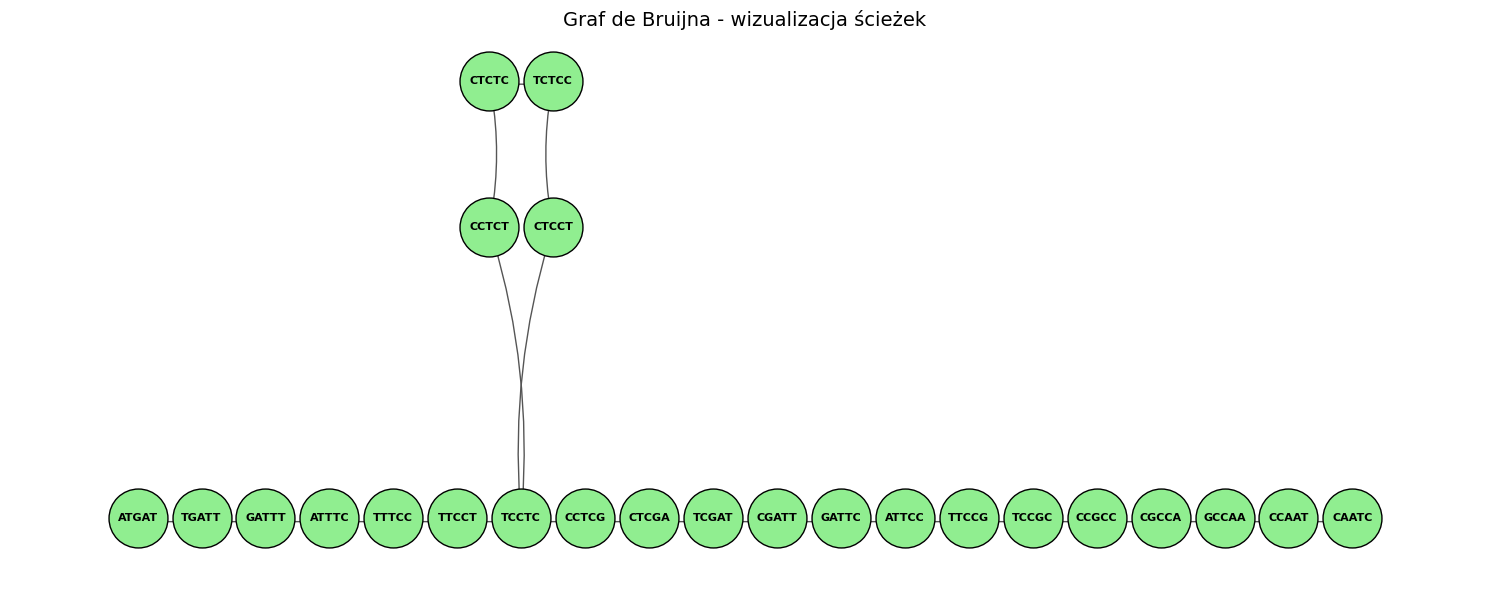

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Dane
genome = "ATGATTTCCTCTCCTCGATTCCGCCAATC"
k = 6
edges = []
for i in range(len(genome) - k + 1):
    kmer = genome[i:i+k]
    edges.append((kmer[:-1], kmer[1:]))

G = nx.DiGraph()
G.add_edges_from(edges)

# 2. Ręczne definiowanie pozycji dla czytelności (układ liniowy z pętlą)
pos = {}

# Grupy węzłów
pre_loop = ['ATGAT', 'TGATT', 'GATTT', 'ATTTC', 'TTTCC', 'TTCCT']
hub = 'TCCTC'
loop_nodes = ['CCTCT', 'CTCTC', 'TCTCC', 'CTCCT']
post_loop = ['CCTCG', 'CTCGA', 'TCGAT', 'CGATT', 'GATTC', 'ATTCC', 
             'TTCCG', 'TCCGC', 'CCGCC', 'CGCCA', 'GCCAA', 'CCAAT', 'CAATC']

# Pozycjonowanie
# A. Część przed pętlą (y=0)
for i, node in enumerate(pre_loop):
    pos[node] = (i, 0)

# B. Węzeł węzłowy (x=6, y=0)
hub_x = len(pre_loop)
pos[hub] = (hub_x, 0)

# C. Pętla (nad węzłem węzłowym)
pos['CCTCT'] = (hub_x - 0.5, 1.0)
pos['CTCTC'] = (hub_x - 0.5, 1.5)
pos['TCTCC'] = (hub_x + 0.5, 1.5)
pos['CTCCT'] = (hub_x + 0.5, 1.0)

# D. Część za pętlą (y=0)
start_x = hub_x + 1
for i, node in enumerate(post_loop):
    pos[node] = (start_x + i, 0)

# 3. Rysowanie
plt.figure(figsize=(15, 6))
nx.draw_networkx_nodes(G, pos, node_size=1800, node_color='lightgreen', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
# connectionstyle='arc3,rad=0.1' dodaje lekkie łuki strzałkom
nx.draw_networkx_edges(G, pos, edge_color='#555555', arrowsize=15, connectionstyle='arc3,rad=0.1')

plt.axis('off')
plt.tight_layout()
plt.show()

**3c. Contigi w assembly graphie**

Chcemy z grafu de Bruijna uzyskać contigi, czyli maksymalne ścieżki, w których w środku ścieżki każdy
wierzchołek ma in-degree = 1 i out-degree = 1 (brak rozgałęzień).
1) Zidentyfikuj wierzchołki, które mają in-degree ≠ 1 lub out-degree ≠ 1 – to są potencjalne początki lub
końce contigów.
2) Dla każdego początkowego węzła lub węzła o in-degree >1 lub out-degree>1 rozpocznij ścieżkę po
grafie aż nie natrafisz na węzeł końcowy albo na węzeł o in-degree >1 lub out-degree>1. Ważne:
warunkiem odbycia ścieżki jest obecność przynajmniej jednego węzła o in-degree=1 i out-degree=1.
3) Zapisz sekwencję contigu:
    - pierwszy wierzchołek daje pierwsze 5 nukleotydów,
    - każdy kolejny wierzchołek „dokleja” na końcu 1 nukleotyd.

W raporcie wypisz wszystkie contigi i ich sekwencje.
Podpowiedź (opcjonalny Python):
Możesz napisać krótki skrypt, który:
    - generuje k-mery,
    - zlicza in/out-degree,
    - wypisuje contigi jako ścieżki w grafie.

W takim wypadku proszę załączyć kod do raportu!

**3d. Czy genom jest jednoznaczny?**

Na podstawie uzyskanego grafu/contigów:
1) Czy jesteś w stanie jednoznacznie odtworzyć cały „genom” (sekwencję podaną na początku)?
2) Jeżeli nie, zaprojektuj najkrótszą sekwencję (długi odczyt), która przechodzi przez odpowiednie miejsce
w genomie tak, by usunąć niejednoznaczność w grafie.
    - Zapisz proponowaną sekwencję długiego odczytu.
    - Krótko wyjaśnij, dlaczego taka sekwencja rozwiązuje problem.